<div dir="rtl" style="text-align:right">

# תרגול 11 — ממודל לינארי ל־MLP


בתרגול זה נעבור ממודל לינארי לרשת נוירונים אמיתית:

```text
Linear classifier
→ Activation functions
→ Multi-Layer Perceptron
→ Optimizer comparison
→ Loss functions
→ Dropout
→ Batch Normalization
→ train() / eval()
```

נשתמש בבעיית **XOR רועשת**, כי היא מדגימה היטב למה מודל לינארי אינו מספיק.

</div>

<div dir="rtl" style="text-align:right">

## 0. Setup

</div>

In [37]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
from torch import nn

torch.manual_seed(42)
np.random.seed(42)
torch.set_num_threads(1)

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Device:", device)

Device: mps


<div dir="rtl" style="text-align:right">

## 1. יצירת XOR Dataset

ב־XOR, המחלקה החיובית מתקבלת כאשר שני הקלטים נמצאים בצדדים מנוגדים של 0.

כלומר:

```text
x1 חיובי, x2 שלילי → class 1
x1 שלילי, x2 חיובי → class 1
אחרת → class 0
```

</div>

In [38]:
def make_noisy_xor(n_samples=600, label_noise=0.03, seed=42):
    rng = np.random.default_rng(seed)

    X = rng.uniform(-1.5, 1.5, size=(n_samples, 2)).astype(np.float32)

    # XOR by quadrants:
    # positive class when x1 and x2 have opposite signs.
    y = ((X[:, 0] * X[:, 1]) < 0).astype(np.float32)

    # Flip a small percentage of labels to make the task more realistic.
    flip_mask = rng.random(n_samples) < label_noise
    y[flip_mask] = 1 - y[flip_mask]

    return X, y


X_np, y_np = make_noisy_xor()

X_train_np, X_temp_np, y_train_np, y_temp_np = train_test_split(
    X_np,
    y_np,
    test_size=0.40,
    random_state=42,
    stratify=y_np
)

X_val_np, X_test_np, y_val_np, y_test_np = train_test_split(
    X_temp_np,
    y_temp_np,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_np
)

def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32, device=device)

X_train = to_tensor(X_train_np)
X_val = to_tensor(X_val_np)
X_test = to_tensor(X_test_np)

y_train = to_tensor(y_train_np).view(-1, 1)
y_val = to_tensor(y_val_np).view(-1, 1)
y_test = to_tensor(y_test_np).view(-1, 1)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: torch.Size([360, 2]) torch.Size([360, 1])
Validation: torch.Size([120, 2]) torch.Size([120, 1])
Test: torch.Size([120, 2]) torch.Size([120, 1])


<div dir="rtl" style="text-align:right">

## תרגיל 1 — EDA וויזואליזציה של XOR

1. הציגו את מספר הדוגמאות בכל split.
2. בדקו את איזון המחלקות.
3. ציירו scatter plot של כל הדאטה.
4. הסבירו למה קו ישר אחד לא יכול להפריד נכון בין המחלקות.

</div>

Train size: 360
Validation size: 120
Test size: 120
Overall positive rate: 0.5
Train positive rate: 0.5
Validation positive rate: 0.5
Test positive rate: 0.5


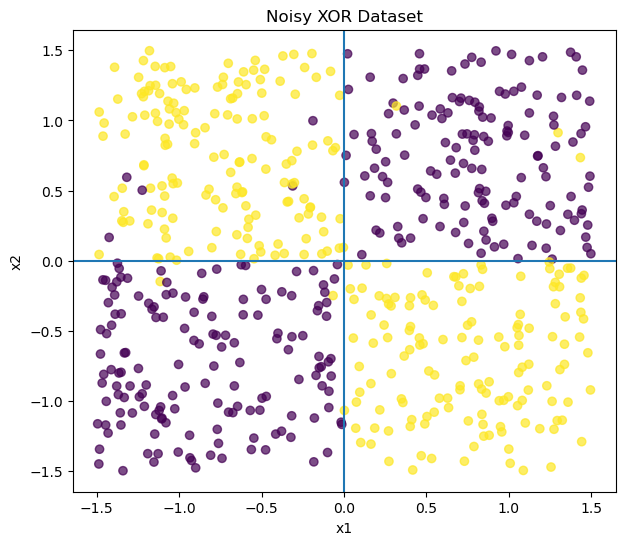

In [39]:
# TODO:
# הציגו counts ו-class balance

print("Train size:", len(X_train_np))
print("Validation size:", len(X_val_np))
print("Test size:", len(X_test_np))

print("Overall positive rate:", y_np.mean())
print("Train positive rate:", y_train_np.mean())
print("Validation positive rate:", y_val_np.mean())
print("Test positive rate:", y_test_np.mean())
# צרו scatter plot של X_np לפי y_np
plt.figure(figsize=(7, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, alpha=0.7)
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Noisy XOR Dataset")
plt.show()



<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
print("Train size:", len(X_train_np))
print("Validation size:", len(X_val_np))
print("Test size:", len(X_test_np))

print("Overall positive rate:", y_np.mean())
print("Train positive rate:", y_train_np.mean())
print("Validation positive rate:", y_val_np.mean())
print("Test positive rate:", y_test_np.mean())

plt.figure(figsize=(7, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, alpha=0.7)
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Noisy XOR Dataset")
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

## 2. פונקציות עזר לאימון ולהצגה

</div>

In [40]:
loss_fn = nn.BCEWithLogitsLoss()

def accuracy_from_logits(logits, y_true):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    return (predictions == y_true).float().mean().item()


def train_binary_model(
    model,
    optimizer,
    epochs=200,
    X_train_data=X_train,
    y_train_data=y_train,
    X_val_data=X_val,
    y_val_data=y_val
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        train_logits = model(X_train_data)
        train_loss = loss_fn(train_logits, y_train_data)
        train_loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            val_logits = model(X_val_data)
            val_loss = loss_fn(val_logits, y_val_data)

            train_accuracy = accuracy_from_logits(train_logits, y_train_data)
            val_accuracy = accuracy_from_logits(val_logits, y_val_data)

        history["train_loss"].append(train_loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

    return pd.DataFrame(history)


def evaluate_binary_model(model, X_data, y_data):
    model.eval()

    with torch.no_grad():
        logits = model(X_data)
        loss = loss_fn(logits, y_data).item()
        accuracy = accuracy_from_logits(logits, y_data)
        predictions = (torch.sigmoid(logits) >= 0.5).int()

    return {
        "loss": loss,
        "accuracy": accuracy,
        "predictions": predictions.detach().cpu().numpy().ravel()
    }


def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("BCE loss")
    plt.title(title)
    plt.legend()
    plt.show()


def plot_decision_boundary(model, X_values, y_values, title):
    x1_min, x1_max = X_values[:, 0].min() - 0.2, X_values[:, 0].max() + 0.2
    x2_min, x2_max = X_values[:, 1].min() - 0.2, X_values[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 250),
        np.linspace(x2_min, x2_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_tensor = to_tensor(grid)

    model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(model(grid_tensor))
        predicted_class = (probabilities >= 0.5).float()

    zz = predicted_class.detach().cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], alpha=0.25)
    plt.scatter(X_values[:, 0], X_values[:, 1], c=y_values, alpha=0.7)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

<div dir="rtl" style="text-align:right">

## 3. מודל לינארי — האם הוא מסוגל לפתור XOR?

נשתמש במודל:

```text
logit = w1*x1 + w2*x2 + b
```

זה יוצר גבול החלטה שהוא קו ישר.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 2 — אימון Linear Classifier

1. צרו `nn.Linear(2, 1)`.
2. אמנו אותו עם Adam.
3. הציגו loss curves.
4. חשבו test accuracy.
5. ציירו decision boundary.

</div>

Linear parameters: 3
Linear test loss: 0.7013648152351379
Linear test accuracy: 0.4833333492279053


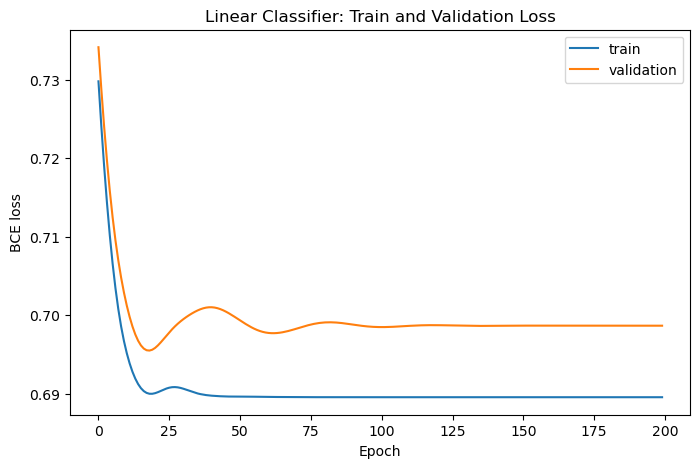

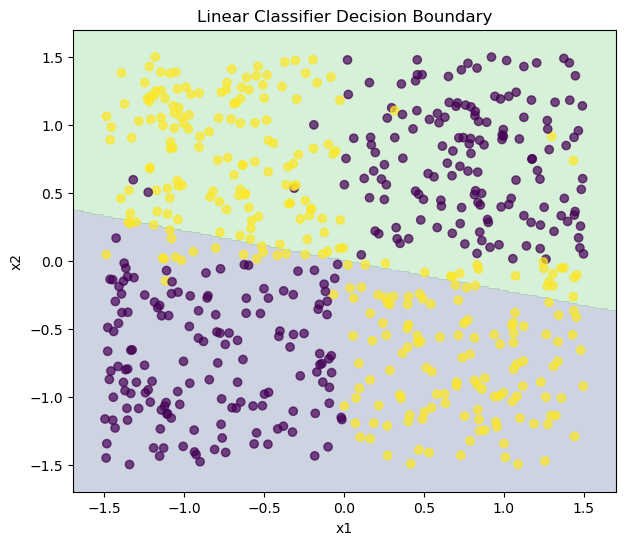

In [41]:
torch.manual_seed(42)

# linear_model = ...
linear_model = nn.Linear(2, 1).to(device)

# optimizer = ...
linear_optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.03)

# linear_history = train_binary_model(...)
linear_history = train_binary_model(
    linear_model,
    linear_optimizer,
    epochs=200
)

# evaluate_binary_model(...)
linear_test_result = evaluate_binary_model(
    linear_model,
    X_test,
    y_test
)

print("Linear parameters:", count_parameters(linear_model))
print("Linear test loss:", linear_test_result["loss"])
print("Linear test accuracy:", linear_test_result["accuracy"])

# plot_history(...)
plot_history(
    linear_history,
    "Linear Classifier: Train and Validation Loss"
)

# plot_decision_boundary(...)
plot_decision_boundary(
    linear_model,
    X_np,
    y_np,
    "Linear Classifier Decision Boundary"
)


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
torch.manual_seed(42)

linear_model = nn.Linear(2, 1).to(device)
linear_optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.03)

linear_history = train_binary_model(
    linear_model,
    linear_optimizer,
    epochs=200
)

linear_test_result = evaluate_binary_model(
    linear_model,
    X_test,
    y_test
)

print("Linear parameters:", count_parameters(linear_model))
print("Linear test loss:", linear_test_result["loss"])
print("Linear test accuracy:", linear_test_result["accuracy"])

plot_history(
    linear_history,
    "Linear Classifier: Train and Validation Loss"
)

plot_decision_boundary(
    linear_model,
    X_np,
    y_np,
    "Linear Classifier Decision Boundary"
)
```

</details>

<div dir="rtl" style="text-align:right">

## 4. Activation Functions

נשווה שלוש פונקציות:

- Sigmoid
- Tanh
- ReLU

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 3 — ויזואליזציה של Activations

ציירו כל פונקציה בגרף נפרד עבור ערכי x בין 6- ל־6.

לאחר מכן ענו:

1. מה טווח הפלט של כל פונקציה?
2. איזו פונקציה יכולה להיכנס ל־saturation?
3. איזו פונקציה מחזירה 0 עבור קלט שלילי?
4. למה בלי activation כמה שכבות Linear עדיין שקולות לשכבה לינארית אחת?

</div>

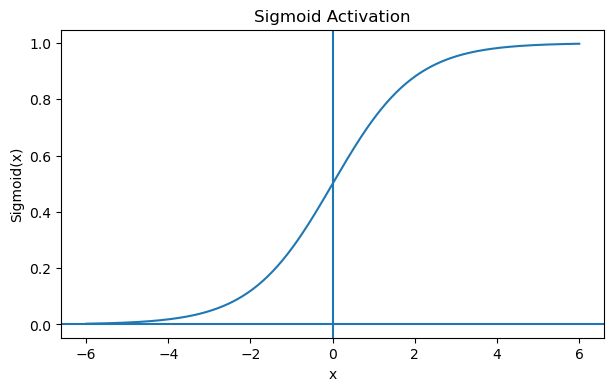

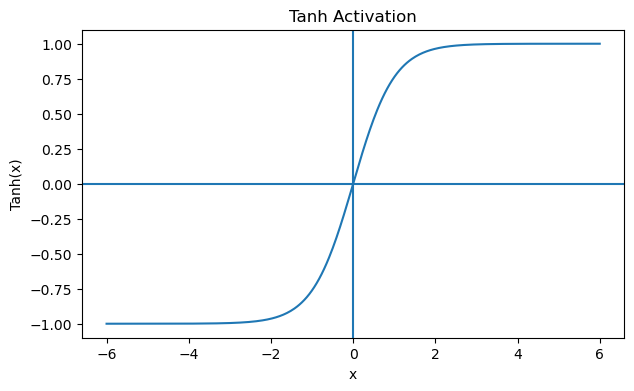

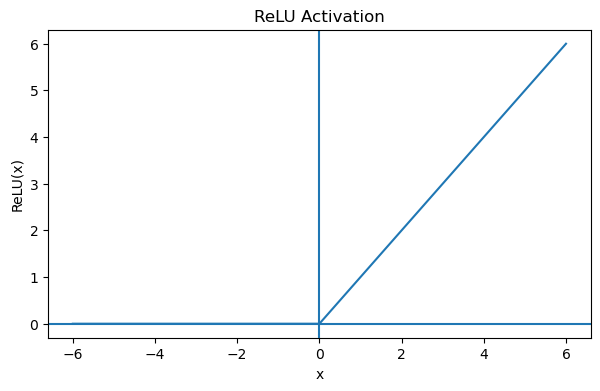

In [42]:
x_values = torch.linspace(-6, 6, 400)

plt.figure(figsize=(7, 4))
plt.plot(x_values.numpy(), torch.sigmoid(x_values).numpy())
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Activation")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x_values.numpy(), torch.tanh(x_values).numpy())
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("Tanh(x)")
plt.title("Tanh Activation")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x_values.numpy(), torch.relu(x_values).numpy())
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.title("ReLU Activation")
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
x_values = torch.linspace(-6, 6, 400)

plt.figure(figsize=(7, 4))
plt.plot(x_values.numpy(), torch.sigmoid(x_values).numpy())
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Activation")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x_values.numpy(), torch.tanh(x_values).numpy())
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("Tanh(x)")
plt.title("Tanh Activation")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x_values.numpy(), torch.relu(x_values).numpy())
plt.axhline(0)
plt.axvline(0)
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.title("ReLU Activation")
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

## 5. בניית MLP גמיש

המבנה:

```text
2 inputs
→ Linear
→ Activation
→ Linear
→ Activation
→ Linear
→ 1 logit
```

</div>

In [43]:
class FlexibleMLP(nn.Module):
    def __init__(
        self,
        input_dim=2,
        hidden_dim=16,
        activation="relu",
        dropout=0.0,
        batchnorm=False
    ):
        super().__init__()

        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid
        }

        if activation not in activation_map:
            raise ValueError(f"Unsupported activation: {activation}")

        Activation = activation_map[activation]

        layers = [
            nn.Linear(input_dim, hidden_dim)
        ]

        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden_dim))

        layers.append(Activation())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden_dim, hidden_dim))

        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden_dim))

        layers.append(Activation())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        # Raw logit: no Sigmoid here because BCEWithLogitsLoss includes it.
        layers.append(nn.Linear(hidden_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

<div dir="rtl" style="text-align:right">

## תרגיל 4 — אימון MLP על XOR

1. צרו MLP עם ReLU.
2. אמנו עם Adam.
3. השוו את מספר הפרמטרים למודל הלינארי.
4. חשבו test accuracy.
5. ציירו loss curves ו־decision boundary.

</div>

Linear parameter count: 3
MLP parameter count: 337
MLP test loss: 0.1246919110417366
MLP test accuracy: 0.9416667222976685


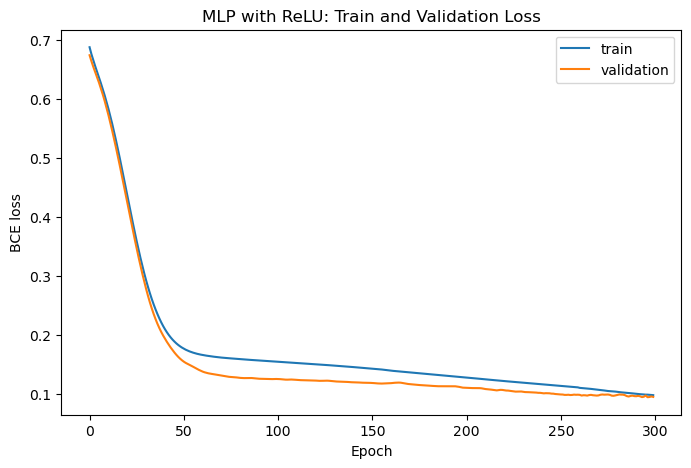

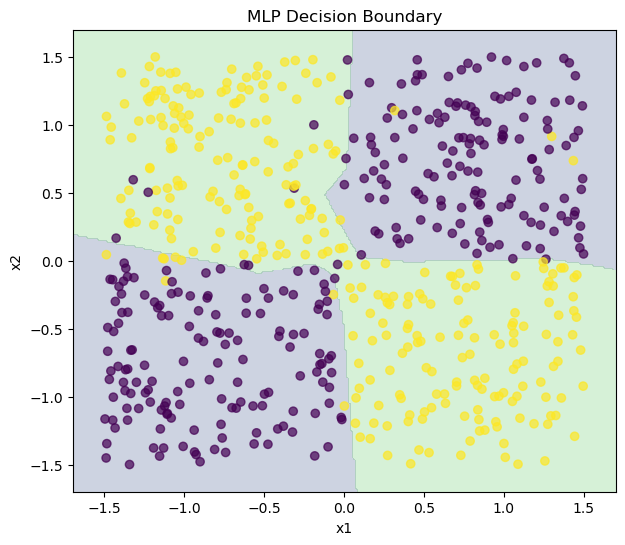

In [44]:
# TODO:

torch.manual_seed(42)

mlp_model = FlexibleMLP(
    activation="relu",
    dropout=0.0,
    batchnorm=False
).to(device)

mlp_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.01
)

mlp_history = train_binary_model(
    mlp_model,
    mlp_optimizer,
    epochs=300
)

mlp_test_result = evaluate_binary_model(
    mlp_model,
    X_test,
    y_test
)
# plots
print("Linear parameter count:", count_parameters(linear_model))
print("MLP parameter count:", count_parameters(mlp_model))
print("MLP test loss:", mlp_test_result["loss"])
print("MLP test accuracy:", mlp_test_result["accuracy"])

plot_history(
    mlp_history,
    "MLP with ReLU: Train and Validation Loss"
)

plot_decision_boundary(
    mlp_model,
    X_np,
    y_np,
    "MLP Decision Boundary"
)



<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
torch.manual_seed(42)

mlp_model = FlexibleMLP(
    activation="relu",
    dropout=0.0,
    batchnorm=False
).to(device)

mlp_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.01
)

mlp_history = train_binary_model(
    mlp_model,
    mlp_optimizer,
    epochs=300
)

mlp_test_result = evaluate_binary_model(
    mlp_model,
    X_test,
    y_test
)

print("Linear parameter count:", count_parameters(linear_model))
print("MLP parameter count:", count_parameters(mlp_model))
print("MLP test loss:", mlp_test_result["loss"])
print("MLP test accuracy:", mlp_test_result["accuracy"])

plot_history(
    mlp_history,
    "MLP with ReLU: Train and Validation Loss"
)

plot_decision_boundary(
    mlp_model,
    X_np,
    y_np,
    "MLP Decision Boundary"
)
```

</details>

<div dir="rtl" style="text-align:right">

## 6. השוואת Optimizers

נשווה:

- SGD
- SGD + Momentum
- Adam

כדי שההשוואה תהיה הוגנת, כל מודל מתחיל מאותו seed ובאותה ארכיטקטורה.

</div>

In [45]:
optimizer_configs = {
    "SGD": {
        "builder": lambda params: torch.optim.SGD(params, lr=0.10)
    },
    "SGD + Momentum": {
        "builder": lambda params: torch.optim.SGD(params, lr=0.10, momentum=0.90)
    },
    "Adam": {
        "builder": lambda params: torch.optim.Adam(params, lr=0.01)
    }
}

optimizer_histories = {}
optimizer_models = {}
optimizer_results = []

for optimizer_name, config in optimizer_configs.items():
    torch.manual_seed(123)

    model = FlexibleMLP(
        activation="relu",
        dropout=0.0,
        batchnorm=False
    ).to(device)

    optimizer = config["builder"](model.parameters())

    history = train_binary_model(
        model,
        optimizer,
        epochs=200
    )

    test_result = evaluate_binary_model(model, X_test, y_test)

    optimizer_histories[optimizer_name] = history
    optimizer_models[optimizer_name] = model

    optimizer_results.append({
        "optimizer": optimizer_name,
        "final_train_loss": history["train_loss"].iloc[-1],
        "final_val_loss": history["val_loss"].iloc[-1],
        "best_val_accuracy": history["val_accuracy"].max(),
        "test_accuracy": test_result["accuracy"]
    })

optimizer_results_df = pd.DataFrame(optimizer_results)
optimizer_results_df

,optimizer,final_train_loss,final_val_loss,best_val_accuracy,test_accuracy
0,SGD,0.237928,0.237839,0.975000,0.933333
1,SGD + Momentum,0.139649,0.117220,0.983333,0.941667
2,Adam,0.118088,0.100472,0.983333,0.958333


<div dir="rtl" style="text-align:right">

## תרגיל 5 — ויזואליזציה של Optimizers

1. ציירו validation loss של שלושת ה־optimizers באותו גרף.
2. ציירו validation accuracy באותו גרף.
3. זהו מי מתכנס מהר יותר.
4. בדקו האם optimizer שמתכנס מהר יותר תמיד נותן test accuracy גבוהה יותר.

</div>

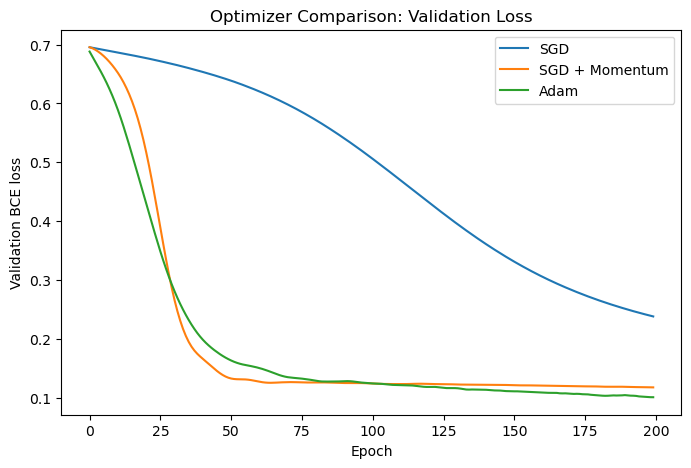

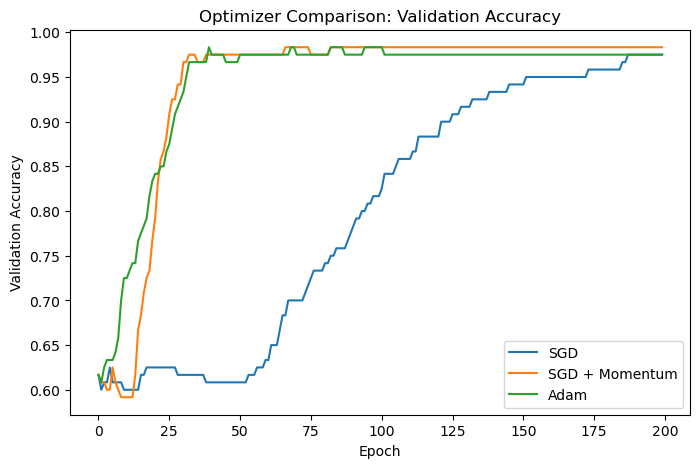

In [46]:
# TODO:
# plot validation loss for optimizer_histories
# plot validation accuracy for optimizer_histories

plt.figure(figsize=(8, 5))
for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history["val_loss"],
        label=optimizer_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation BCE loss")
plt.title("Optimizer Comparison: Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history["val_accuracy"],
        label=optimizer_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison: Validation Accuracy")
plt.legend()
plt.show()





<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
plt.figure(figsize=(8, 5))
for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history["val_loss"],
        label=optimizer_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation BCE loss")
plt.title("Optimizer Comparison: Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history["val_accuracy"],
        label=optimizer_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison: Validation Accuracy")
plt.legend()
plt.show()

optimizer_results_df
```

</details>

<div dir="rtl" style="text-align:right">

## 7. השוואת Activations בתוך MLP

נשווה ReLU, Tanh ו־Sigmoid באותה ארכיטקטורה ועם Adam.

</div>

In [47]:
activation_names = ["relu", "tanh", "sigmoid"]

activation_histories = {}
activation_models = {}
activation_results = []

for activation_name in activation_names:
    torch.manual_seed(123)

    model = FlexibleMLP(
        activation=activation_name,
        dropout=0.0,
        batchnorm=False
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    history = train_binary_model(
        model,
        optimizer,
        epochs=200
    )

    test_result = evaluate_binary_model(model, X_test, y_test)

    activation_histories[activation_name] = history
    activation_models[activation_name] = model

    activation_results.append({
        "activation": activation_name,
        "final_train_loss": history["train_loss"].iloc[-1],
        "final_val_loss": history["val_loss"].iloc[-1],
        "best_val_accuracy": history["val_accuracy"].max(),
        "test_accuracy": test_result["accuracy"]
    })

activation_results_df = pd.DataFrame(activation_results)
activation_results_df

,activation,final_train_loss,final_val_loss,best_val_accuracy,test_accuracy
0,relu,0.118088,0.100472,0.983333,0.958333
1,tanh,0.096763,0.075393,0.983333,0.975000
2,sigmoid,0.137910,0.117015,0.983333,0.950000


<div dir="rtl" style="text-align:right">

## תרגיל 6 — ויזואליזציה של Activations באימון

1. ציירו validation loss עבור כל activation.
2. ציירו validation accuracy.
3. בדקו אם Sigmoid מתכנסת לאט יותר.
4. השוו test accuracy.

</div>

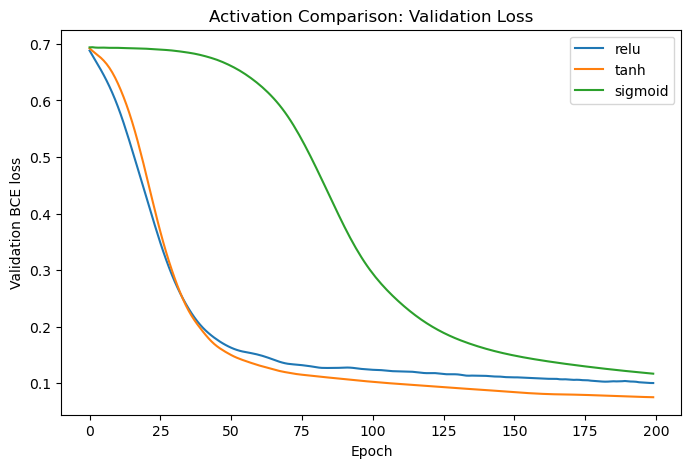

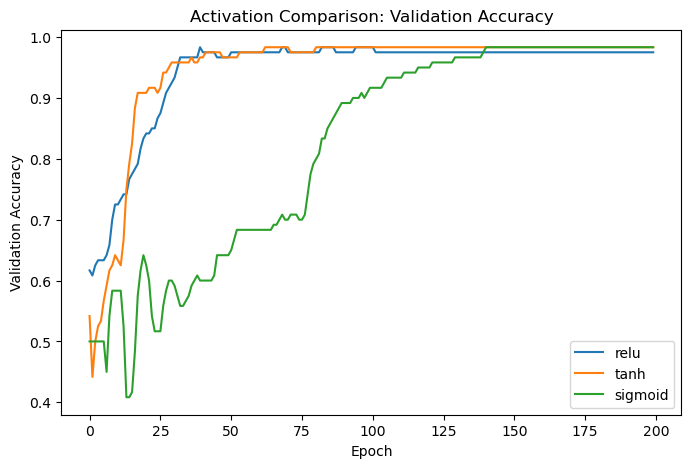

In [48]:
# TODO:
# plot activation_histories

plt.figure(figsize=(8, 5))
for activation_name, history in activation_histories.items():
    plt.plot(
        history["val_loss"],
        label=activation_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation BCE loss")
plt.title("Activation Comparison: Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for activation_name, history in activation_histories.items():
    plt.plot(
        history["val_accuracy"],
        label=activation_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Activation Comparison: Validation Accuracy")
plt.legend()
plt.show()




<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
plt.figure(figsize=(8, 5))
for activation_name, history in activation_histories.items():
    plt.plot(
        history["val_loss"],
        label=activation_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation BCE loss")
plt.title("Activation Comparison: Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for activation_name, history in activation_histories.items():
    plt.plot(
        history["val_accuracy"],
        label=activation_name
    )
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Activation Comparison: Validation Accuracy")
plt.legend()
plt.show()

activation_results_df
```

</details>

<div dir="rtl" style="text-align:right">

## 8. BCEWithLogitsLoss

המודל מחזיר **logits**, לא probabilities.

`BCEWithLogitsLoss` משלבת:

```text
Sigmoid + Binary Cross Entropy
```

בצורה נומרית יציבה.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 7 — Logits מול Probabilities

1. קחו batch קטן של logits.
2. המירו ל־probabilities עם Sigmoid.
3. השוו:
   - `BCEWithLogitsLoss(logits, y)`
   - `BCELoss(sigmoid(logits), y)`
4. בדקו שהערכים כמעט זהים.

</div>

In [49]:
# TODO:
logits = torch.tensor(
    [[-3.0], [-0.5], [0.0], [1.5], [4.0]],
    dtype=torch.float32,
    device=device
)

targets = torch.tensor(
    [[0.0], [0.0], [1.0], [1.0], [1.0]],
    dtype=torch.float32,
    device=device
)

probabilities = torch.sigmoid(logits)

loss_with_logits = nn.BCEWithLogitsLoss()(logits, targets)
loss_after_sigmoid = nn.BCELoss()(probabilities, targets)

display(pd.DataFrame({
    "logit": logits.detach().cpu().numpy().ravel(),
    "probability": probabilities.detach().cpu().numpy().ravel(),
    "target": targets.detach().cpu().numpy().ravel()
}))

print("BCEWithLogitsLoss:", loss_with_logits.item())
print("Sigmoid + BCELoss:", loss_after_sigmoid.item())
print(
    "Almost equal:",
    torch.allclose(
        loss_with_logits,
        loss_after_sigmoid,
        atol=1e-6
    )
)


,logit,probability,target
0,-3.0,0.047426,0.0
1,-0.5,0.377541,0.0
2,0.0,0.500000,1.0
3,1.5,0.817574,1.0
4,4.0,0.982014,1.0


BCEWithLogitsLoss: 0.2870749533176422
Sigmoid + BCELoss: 0.2870749533176422
Almost equal: True


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
logits = torch.tensor(
    [[-3.0], [-0.5], [0.0], [1.5], [4.0]],
    dtype=torch.float32,
    device=device
)

targets = torch.tensor(
    [[0.0], [0.0], [1.0], [1.0], [1.0]],
    dtype=torch.float32,
    device=device
)

probabilities = torch.sigmoid(logits)

loss_with_logits = nn.BCEWithLogitsLoss()(logits, targets)
loss_after_sigmoid = nn.BCELoss()(probabilities, targets)

display(pd.DataFrame({
    "logit": logits.detach().cpu().numpy().ravel(),
    "probability": probabilities.detach().cpu().numpy().ravel(),
    "target": targets.detach().cpu().numpy().ravel()
}))

print("BCEWithLogitsLoss:", loss_with_logits.item())
print("Sigmoid + BCELoss:", loss_after_sigmoid.item())
print(
    "Almost equal:",
    torch.allclose(
        loss_with_logits,
        loss_after_sigmoid,
        atol=1e-6
    )
)
```

</details>

<div dir="rtl" style="text-align:right">

## 9. Dropout

בזמן אימון, Dropout מאפס באקראי חלק מה־activations.  
בזמן evaluation הוא כבוי.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 8 — Dropout ב־train() וב־eval()

1. צרו `nn.Dropout(p=0.5)`.
2. העבירו tensor של 1-ים פעמיים ב־train mode.
3. העבירו אותו פעמיים ב־eval mode.
4. הסבירו למה הפלט שונה.

</div>

MLP -> activation -> Dropout -> activation -> output

In [50]:
# TODO:
# dropout_layer = ...
dropout_layer = nn.Dropout(p=0.5).to(device)

# input_ones = ...
input_ones = torch.ones((5, 5), dtype=torch.float32, device=device)

# dropout_layer.train()
dropout_layer.train()

# train_output_1 = ...
train_output_1 = dropout_layer(input_ones)

# train_output_2 = ...
train_output_2 = dropout_layer(input_ones)

# dropout_layer.eval()
dropout_layer.eval()

# eval_output_1 = ...
eval_output_1 = dropout_layer(input_ones)

# eval_output_2 = ...
eval_output_2 = dropout_layer(input_ones)

print(input_ones)
print("Train output 1:\n", train_output_1)
print("Train output 2:\n", train_output_2)
print("Eval output 1:\n", eval_output_1)
print("Eval output 2:\n", eval_output_2)


tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], device='mps:0')
Train output 1:
 tensor([[0., 0., 0., 2., 2.],
        [2., 2., 2., 0., 0.],
        [0., 2., 0., 2., 2.],
        [2., 2., 2., 2., 0.],
        [0., 0., 2., 0., 2.]], device='mps:0')
Train output 2:
 tensor([[0., 2., 0., 0., 2.],
        [0., 2., 2., 0., 0.],
        [0., 2., 2., 2., 2.],
        [2., 2., 2., 0., 0.],
        [2., 0., 0., 0., 2.]], device='mps:0')
Eval output 1:
 tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], device='mps:0')
Eval output 2:
 tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], device='mps:0')


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
dropout_layer = nn.Dropout(p=0.5)
input_ones = torch.ones((4, 10), device=device)

dropout_layer.train()
train_output_1 = dropout_layer(input_ones)
train_output_2 = dropout_layer(input_ones)

dropout_layer.eval()
eval_output_1 = dropout_layer(input_ones)
eval_output_2 = dropout_layer(input_ones)

print("Train output 1:")
print(train_output_1)
print("\nTrain output 2:")
print(train_output_2)
print("\nEval output 1:")
print(eval_output_1)
print("\nEval output 2:")
print(eval_output_2)

print(
    "\nTrain outputs equal:",
    torch.equal(train_output_1, train_output_2)
)
print(
    "Eval outputs equal:",
    torch.equal(eval_output_1, eval_output_2)
)
```

</details>

<div dir="rtl" style="text-align:right">

## 10. Batch Normalization

נבדוק מה BatchNorm עושה ל־activations של batch.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 9 — התפלגות לפני ואחרי BatchNorm

1. צרו activations עם mean בערך 10 ו־std בערך 5.
2. הפעילו `BatchNorm1d`.
3. הדפיסו mean ו־std לכל feature לפני ואחרי.
4. ציירו histogram לפני ואחרי בגרפים נפרדים.

</div>

Mean before: [10.358799  9.889735 10.281683  9.901876]
Std before: [4.810786  4.871468  5.1932626 5.0674996]
Mean after: [-6.5192580e-08 -8.1956387e-08  5.2619725e-08 -1.7881393e-07]
Std after: [0.9999998 0.9999998 0.9999998 0.9999999]


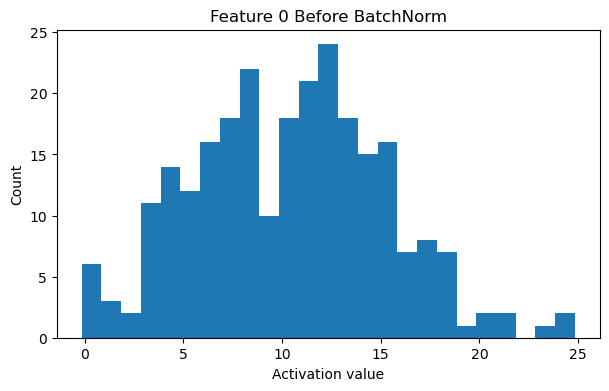

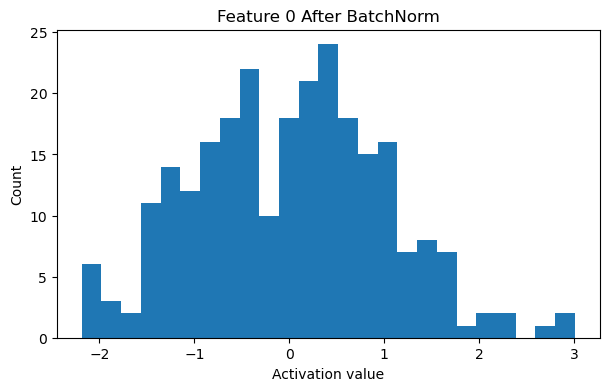

In [51]:

torch.manual_seed(42)

raw_activations = (
    torch.randn((256, 4), device=device) * 5.0 + 10.0
)

batch_norm = nn.BatchNorm1d(4).to(device)
batch_norm.train()

normalized_activations = batch_norm(raw_activations)

print(
    "Mean before:",
    raw_activations.mean(dim=0).detach().cpu().numpy()
)
print(
    "Std before:",
    raw_activations.std(dim=0, unbiased=False).detach().cpu().numpy()
)
print(
    "Mean after:",
    normalized_activations.mean(dim=0).detach().cpu().numpy()
)
print(
    "Std after:",
    normalized_activations.std(dim=0, unbiased=False).detach().cpu().numpy()
)

plt.figure(figsize=(7, 4))
plt.hist(
    raw_activations[:, 0].detach().cpu().numpy(),
    bins=25
)
plt.xlabel("Activation value")
plt.ylabel("Count")
plt.title("Feature 0 Before BatchNorm")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(
    normalized_activations[:, 0].detach().cpu().numpy(),
    bins=25
)
plt.xlabel("Activation value")
plt.ylabel("Count")
plt.title("Feature 0 After BatchNorm")
plt.show()


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
torch.manual_seed(42)

raw_activations = (
    torch.randn((256, 4), device=device) * 5.0 + 10.0
)

batch_norm = nn.BatchNorm1d(4).to(device)
batch_norm.train()

normalized_activations = batch_norm(raw_activations)

print(
    "Mean before:",
    raw_activations.mean(dim=0).detach().cpu().numpy()
)
print(
    "Std before:",
    raw_activations.std(dim=0, unbiased=False).detach().cpu().numpy()
)
print(
    "Mean after:",
    normalized_activations.mean(dim=0).detach().cpu().numpy()
)
print(
    "Std after:",
    normalized_activations.std(dim=0, unbiased=False).detach().cpu().numpy()
)

plt.figure(figsize=(7, 4))
plt.hist(
    raw_activations[:, 0].detach().cpu().numpy(),
    bins=25
)
plt.xlabel("Activation value")
plt.ylabel("Count")
plt.title("Feature 0 Before BatchNorm")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(
    normalized_activations[:, 0].detach().cpu().numpy(),
    bins=25
)
plt.xlabel("Activation value")
plt.ylabel("Count")
plt.title("Feature 0 After BatchNorm")
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

## 11. MLP עם Dropout ו־BatchNorm

נשווה מודל רגיל למודל עם BatchNorm ו־Dropout.

ב־XOR הפשוט, regularization לא בהכרח תשפר תוצאה.  
המטרה היא לבדוק את ההתנהגות ולזכור שהיא שימושית בעיקר כשיש overfitting.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 10 — השוואת מודל רגיל למודל Regularized

אמנו:

1. MLP רגיל.
2. MLP עם `BatchNorm=True` ו־`Dropout=0.30`.

השוו:

- train loss
- validation loss
- test accuracy

</div>

In [ ]:
# TODO:
# train plain_model
plain_model = FlexibleMLP(
    activation="relu",
    dropout=0.0,
    batchnorm=False
).to(device)

optimizer = torch.optim.Adam(plain_model.parameters(), lr=0.01)
history_plain = train_binary_model(
    plain_model,
    optimizer,
    epochs=300
)
test_result_plain = evaluate_binary_model(
    plain_model,
    X_test,
    y_test
)
# train regularized_model
regularized_model = FlexibleMLP(
    activation="relu",
    dropout=0.5,
    batchnorm=True
).to(device)

optimizer = torch.optim.Adam(regularized_model.parameters(), lr=0.01)
history_regularized = train_binary_model(
    regularized_model,
    optimizer,
    epochs=300
)
test_result_regularized = evaluate_binary_model(
    regularized_model,
    X_test,
    y_test
).to(device)
optimizer = torch.optim.Adam(regularized_model.parameters(), lr=0.01)
history_regularized = train_binary_model(
    regularized_model,
    optimizer,
    epochs=300
)
test_result_regularized = evaluate_binary_model(
    regularized_model,
    X_test,
    y_test
).to(device)
# compare histories and results
regularized_results_df = pd.DataFrame({
    "plain_train_loss": history_plain["train_loss"],
    "plain_val_loss": history_plain["val_loss"],
    "regularized_train_loss": history_regularized["train_loss"],
    "regularized_val_loss": history_regularized["val_loss"]
})
regularized_history_df = pd.DataFrame({
    "plain_train_loss": history_plain["train_loss"],
    "plain_val_loss": history_plain["val_loss"],
    "regularized_train_loss": history_regularized["train_loss"],
    "regularized_val_loss": history_regularized["val_loss"]
})



<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
comparison_configs = {
    "Plain MLP": {
        "dropout": 0.0,
        "batchnorm": False
    },
    "BatchNorm + Dropout": {
        "dropout": 0.30,
        "batchnorm": True
    }
}

regularization_histories = {}
regularization_results = []

for model_name, config in comparison_configs.items():
    torch.manual_seed(321)

    model = FlexibleMLP(
        activation="relu",
        dropout=config["dropout"],
        batchnorm=config["batchnorm"]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    history = train_binary_model(
        model,
        optimizer,
        epochs=250
    )

    test_result = evaluate_binary_model(
        model,
        X_test,
        y_test
    )

    regularization_histories[model_name] = history

    regularization_results.append({
        "model": model_name,
        "final_train_loss": history["train_loss"].iloc[-1],
        "final_val_loss": history["val_loss"].iloc[-1],
        "best_val_accuracy": history["val_accuracy"].max(),
        "test_accuracy": test_result["accuracy"]
    })

plt.figure(figsize=(8, 5))
for model_name, history in regularization_histories.items():
    plt.plot(
        history["train_loss"],
        label=f"{model_name} train"
    )
    plt.plot(
        history["val_loss"],
        linestyle="--",
        label=f"{model_name} validation"
    )
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Regularization Comparison")
plt.legend()
plt.show()

pd.DataFrame(regularization_results)
```

</details>

<div dir="rtl" style="text-align:right">

## 12. train() מול eval()

ענו:

1. מה משתנה ב־Dropout?
2. מה משתנה ב־BatchNorm?
3. למה חייבים לקרוא `model.eval()` לפני inference?
4. למה אין להשתמש ב־Sigmoid בשכבת הפלט כשמשתמשים ב־BCEWithLogitsLoss?

</div>

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
summary = {
    "dropout_in_train": "Randomly masks activations and rescales the survivors.",
    "dropout_in_eval": "Disabled; all activations are used.",
    "batchnorm_in_train": "Uses batch statistics and updates running statistics.",
    "batchnorm_in_eval": "Uses stored running mean and variance.",
    "output_layer": "Return raw logits when using BCEWithLogitsLoss."
}

summary
```

</details>

<div dir="rtl" style="text-align:right">

## שאלות סיכום

1. למה מודל לינארי נכשל ב־XOR?
2. למה Activation Function נחוצה?
3. מה ההבדל בין ReLU, Tanh ו־Sigmoid?
4. מה Momentum מוסיף ל־SGD?
5. למה Adam מתכנס לעיתים מהר יותר?
6. מהו Logit?
7. למה משתמשים ב־BCEWithLogitsLoss?
8. מה Dropout עושה בזמן אימון?
9. מה BatchNorm עושה בזמן אימון?
10. למה `model.train()` ו־`model.eval()` חשובים?
11. האם Regularization תמיד משפרת test accuracy?
12. מה יהיה הצעד הבא כדי לבנות MLP למשימה אמיתית?

</div>